# Round 5 EDA 2 — Hint-Driven Analysis

**Focus**: Lead-lag relationships, anti-correlated pairs, cluster behavior.

> *'Find the leaders. Find the lags. Measure the gap. Then use it.'*

> *'STRAWBERRY has the price deviation exactly opposite as RASPBERRY'*

In [1]:
%matplotlib inline
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import warnings; warnings.filterwarnings('ignore')

BG='#0d0d1a'; AX='#141428'
C1='#00d4ff'; C2='#ff6b6b'; C3='#ffd93d'; C4='#6bcb77'
COLORS=['#00d4ff','#ff6b6b','#ffd93d','#6bcb77','#cc5de8','#ff922b','#74c0fc','#f783ac','#a9e34b','#63e6be']
PROD_COLORS=['#00d4ff','#ff6b6b','#ffd93d','#6bcb77','#cc5de8']
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':AX,'text.color':'#e0e0e0',
    'axes.labelcolor':'#e0e0e0','xtick.color':'#e0e0e0','ytick.color':'#e0e0e0',
    'axes.spines.top':False,'axes.spines.right':False,'grid.color':'#2a2a3a','grid.linewidth':0.5})
GROUPS={'GALAXY':['GALAXY_SOUNDS_DARK_MATTER','GALAXY_SOUNDS_BLACK_HOLES','GALAXY_SOUNDS_PLANETARY_RINGS','GALAXY_SOUNDS_SOLAR_WINDS','GALAXY_SOUNDS_SOLAR_FLAMES'],
'SLEEP_POD':['SLEEP_POD_SUEDE','SLEEP_POD_LAMB_WOOL','SLEEP_POD_POLYESTER','SLEEP_POD_NYLON','SLEEP_POD_COTTON'],
'MICROCHIP':['MICROCHIP_CIRCLE','MICROCHIP_OVAL','MICROCHIP_SQUARE','MICROCHIP_RECTANGLE','MICROCHIP_TRIANGLE'],
'PEBBLES':['PEBBLES_XS','PEBBLES_S','PEBBLES_M','PEBBLES_L','PEBBLES_XL'],
'ROBOT':['ROBOT_VACUUMING','ROBOT_MOPPING','ROBOT_DISHES','ROBOT_LAUNDRY','ROBOT_IRONING'],
'UV_VISOR':['UV_VISOR_YELLOW','UV_VISOR_AMBER','UV_VISOR_ORANGE','UV_VISOR_RED','UV_VISOR_MAGENTA'],
'TRANSLATOR':['TRANSLATOR_SPACE_GRAY','TRANSLATOR_ASTRO_BLACK','TRANSLATOR_ECLIPSE_CHARCOAL','TRANSLATOR_GRAPHITE_MIST','TRANSLATOR_VOID_BLUE'],
'PANEL':['PANEL_1X2','PANEL_2X2','PANEL_1X4','PANEL_2X4','PANEL_4X4'],
'OXYGEN':['OXYGEN_SHAKE_MORNING_BREATH','OXYGEN_SHAKE_EVENING_BREATH','OXYGEN_SHAKE_MINT','OXYGEN_SHAKE_CHOCOLATE','OXYGEN_SHAKE_GARLIC'],
'SNACKPACK':['SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA','SNACKPACK_PISTACHIO','SNACKPACK_STRAWBERRY','SNACKPACK_RASPBERRY']}
DATA_DIR = '../../../data/ROUND_5'   # relative to ying_research/Round_5/pak/
dfs=[]
for d in [2,3,4]:
    p=pd.read_csv(f'{DATA_DIR}/prices_round_5_day_{d}.csv',sep=';'); dfs.append(p)
prices=pd.concat(dfs,ignore_index=True)
prices['spread']=prices['ask_price_1']-prices['bid_price_1']
print(f"Loaded {len(prices):,} rows | {prices['product'].nunique()} products | {sorted(prices['day'].unique())} days")

Loaded 1,500,000 rows | 50 products | [np.int64(2), np.int64(3), np.int64(4)] days


## 1. Price Deviation Within Each Category

For each group, compute each product's deviation from the group mean price. This reveals the internal structure — which products are permanently expensive/cheap vs which oscillate.

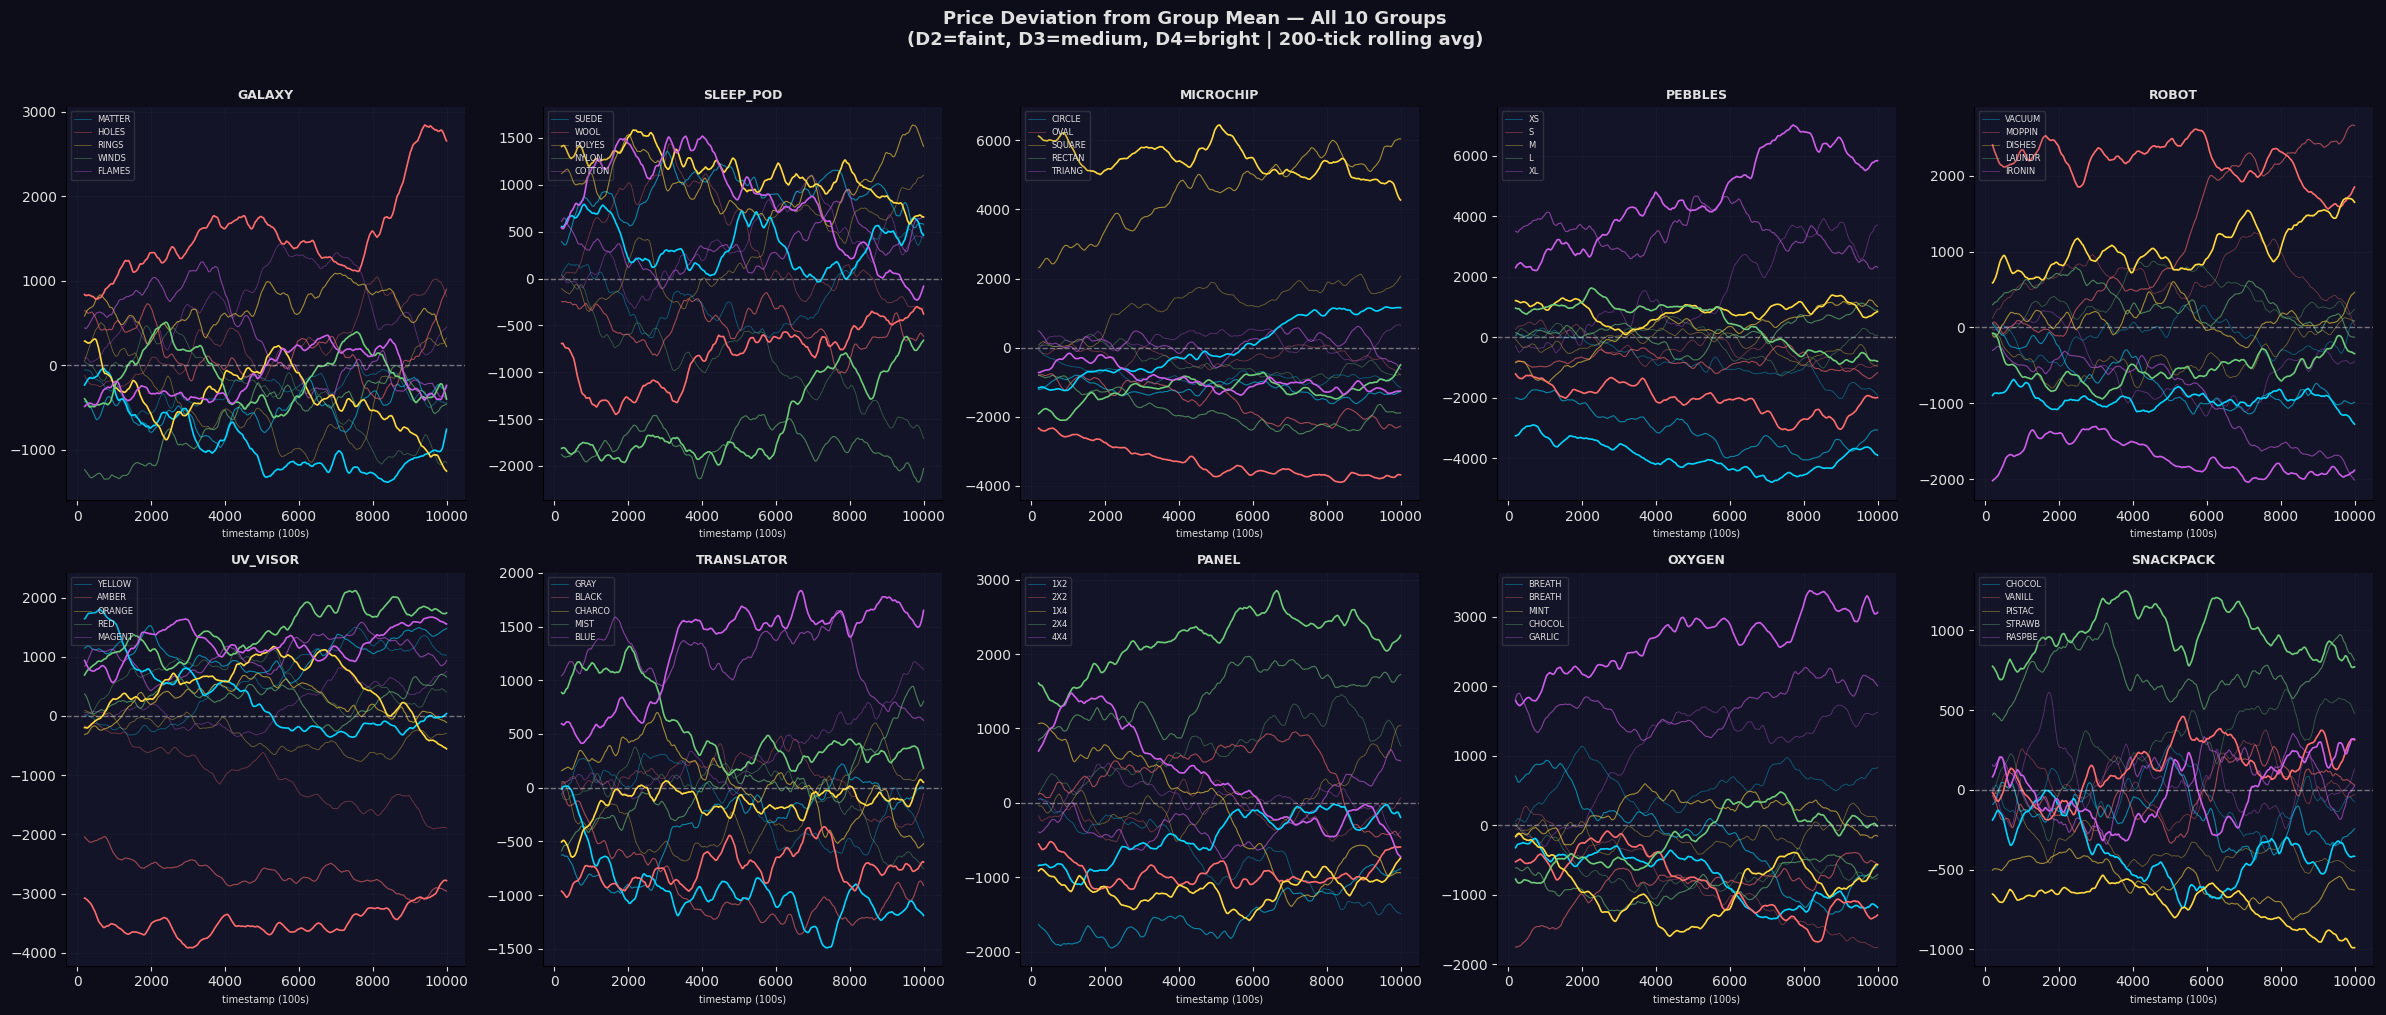

Saved. Look for products that consistently stay above or below zero.


In [2]:
fig,axes=plt.subplots(2,5,figsize=(24,10))
axes=axes.flatten()

for ax,(grp,prods) in zip(axes,GROUPS.items()):
    for d,alpha,lw in [(2,0.4,0.6),(3,0.6,0.8),(4,1.0,1.2)]:
        sub=prices[prices['day']==d]
        pivot=sub[sub['product'].isin(prods)].pivot_table(index='timestamp',columns='product',values='mid_price')
        if pivot.empty: continue
        gm=pivot.mean(axis=1)
        devs=pivot.subtract(gm,axis=0)
        for i,prod in enumerate(prods):
            if prod not in devs.columns: continue
            short=prod.replace(grp+'_','').replace(grp.upper()+'_','').split('_')[-1][:6]
            lbl=short if d==2 else ''
            rolled=devs[prod].rolling(200).mean()
            ax.plot(devs.index//100, rolled, color=PROD_COLORS[i], lw=lw, alpha=alpha, label=lbl)
    ax.axhline(0, color='white', lw=1, ls='--', alpha=0.4)
    ax.set_title(f'{grp}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=6, loc='upper left', framealpha=0.15)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('timestamp (100s)', fontsize=7)

plt.suptitle('Price Deviation from Group Mean — All 10 Groups\n(D2=faint, D3=medium, D4=bright | 200-tick rolling avg)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot1_deviations.png', dpi=100, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved. Look for products that consistently stay above or below zero.')

## 2. The STRAWBERRY vs RASPBERRY Effect

This is the specific example from the hint. Verify the -1.0 correlation and visualize why it's a perfect pairs trade.

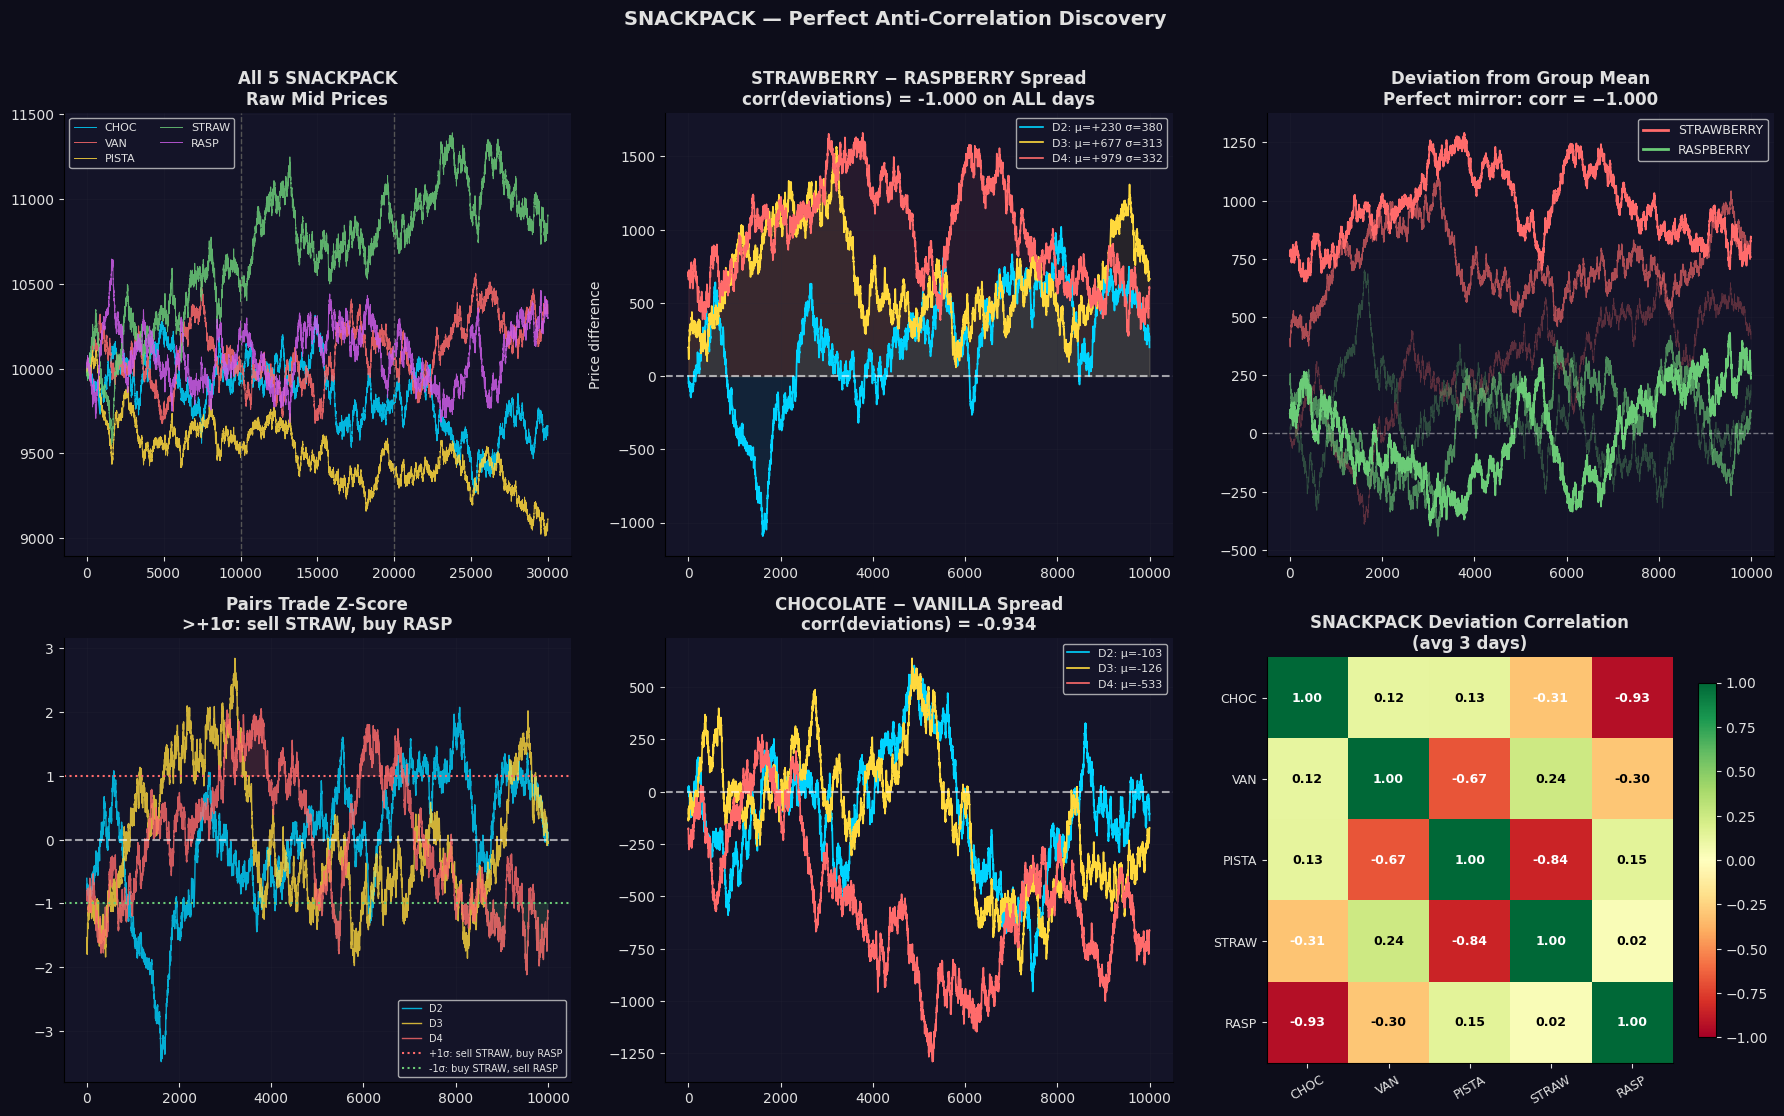

STRAW-RASP: corr=-1.000 | CHOC-VAN: corr=-0.934 | PISTA-RASP: corr=-0.673


In [3]:
fig,axes=plt.subplots(2,3,figsize=(18,11))

SNACKS=['SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA','SNACKPACK_PISTACHIO','SNACKPACK_STRAWBERRY','SNACKPACK_RASPBERRY']
SHORT=['CHOC','VAN','PISTA','STRAW','RASP']

# 1: Raw prices all 5 snackpacks
ax=axes[0,0]
for d in [2,3,4]:
    sub=prices[prices['day']==d]
    for i,(prod,col) in enumerate(zip(SNACKS,PROD_COLORS)):
        s=sub[sub['product']==prod].sort_values('timestamp')
        s_=s.copy(); s_['x']=(d-2)*10000+s_['timestamp']//100
        lbl=SHORT[i] if d==2 else ''
        ax.plot(s_['x'], s_['mid_price'], color=col, lw=0.7, alpha=0.85, label=lbl)
for x in [10000,20000]: ax.axvline(x,color='#555',lw=1,ls='--')
ax.set_title('All 5 SNACKPACK\nRaw Mid Prices', fontweight='bold')
ax.legend(fontsize=8, ncol=2); ax.grid(True,alpha=0.3)

# 2: STRAW-RASP spread
ax=axes[0,1]
for d,col in [(2,C1),(3,C3),(4,C2)]:
    sub=prices[prices['day']==d]
    s=sub[sub['product']=='SNACKPACK_STRAWBERRY'].sort_values('timestamp')['mid_price'].values
    r=sub[sub['product']=='SNACKPACK_RASPBERRY'].sort_values('timestamp')['mid_price'].values
    n=min(len(s),len(r))
    ts=sub[sub['product']=='SNACKPACK_STRAWBERRY'].sort_values('timestamp')['timestamp'].values[:n]
    spread=s[:n]-r[:n]
    ax.plot(ts//100, spread, color=col, lw=1.2, label=f'D{d}: μ={spread.mean():+.0f} σ={spread.std():.0f}')
    ax.fill_between(ts//100, spread, alpha=0.08, color=col)
ax.axhline(0,color='white',lw=1.5,ls='--',alpha=0.6)
ax.set_title('STRAWBERRY − RASPBERRY Spread\ncorr(deviations) = -1.000 on ALL days', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3); ax.set_ylabel('Price difference')

# 3: Deviation from group mean — the mirror image
ax=axes[0,2]
for d in [2,3,4]:
    sub=prices[prices['day']==d]
    pivot=sub[sub['product'].isin(SNACKS)].pivot_table(index='timestamp',columns='product',values='mid_price')
    gm=pivot.mean(axis=1); devs=pivot.subtract(gm,axis=0)
    alpha=0.3+0.35*(d-2); lw=0.5+0.4*(d-2)
    ax.plot(devs.index//100, devs['SNACKPACK_STRAWBERRY'], color=C2, lw=lw, alpha=alpha)
    ax.plot(devs.index//100, devs['SNACKPACK_RASPBERRY'], color=C4, lw=lw, alpha=alpha)
ax.axhline(0,color='white',lw=1,ls='--',alpha=0.4)
from matplotlib.lines import Line2D
handles=[Line2D([0],[0],color=C2,lw=2,label='STRAWBERRY'),Line2D([0],[0],color=C4,lw=2,label='RASPBERRY')]
ax.legend(handles=handles,fontsize=9)
ax.set_title('Deviation from Group Mean\nPerfect mirror: corr = −1.000', fontweight='bold')
ax.grid(True,alpha=0.3)

# 4: Z-score trading signal
ax=axes[1,0]
for d,col in [(2,C1),(3,C3),(4,C2)]:
    sub=prices[prices['day']==d]
    s=sub[sub['product']=='SNACKPACK_STRAWBERRY'].sort_values('timestamp')['mid_price'].values
    r=sub[sub['product']=='SNACKPACK_RASPBERRY'].sort_values('timestamp')['mid_price'].values
    n=min(len(s),len(r))
    ts=sub[sub['product']=='SNACKPACK_STRAWBERRY'].sort_values('timestamp')['timestamp'].values[:n]
    spread=s[:n]-r[:n]
    mu=spread.mean(); sig=spread.std()
    z=(spread-mu)/sig
    ax.plot(ts//100,z,color=col,lw=1.0,alpha=0.8,label=f'D{d}')
ax.axhline(0,color='white',lw=1.5,ls='--',alpha=0.6)
ax.axhline(1,color=C2,lw=1.5,ls=':',label='+1σ: sell STRAW, buy RASP')
ax.axhline(-1,color=C4,lw=1.5,ls=':',label='-1σ: buy STRAW, sell RASP')
ax.fill_between(range(len(z)),z,1,where=z>1,alpha=0.15,color=C2)
ax.fill_between(range(len(z)),z,-1,where=z<-1,alpha=0.15,color=C4)
ax.set_title('Pairs Trade Z-Score\n>+1σ: sell STRAW, buy RASP', fontweight='bold')
ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

# 5: CHOC vs VANILLA
ax=axes[1,1]
for d,col in [(2,C1),(3,C3),(4,C2)]:
    sub=prices[prices['day']==d]
    c=sub[sub['product']=='SNACKPACK_CHOCOLATE'].sort_values('timestamp')['mid_price'].values
    v=sub[sub['product']=='SNACKPACK_VANILLA'].sort_values('timestamp')['mid_price'].values
    n=min(len(c),len(v))
    ts=sub[sub['product']=='SNACKPACK_CHOCOLATE'].sort_values('timestamp')['timestamp'].values[:n]
    spread=c[:n]-v[:n]
    ax.plot(ts//100,spread,color=col,lw=1.2,label=f'D{d}: μ={spread.mean():+.0f}')
ax.axhline(0,color='white',lw=1.5,ls='--',alpha=0.6)
ax.set_title('CHOCOLATE − VANILLA Spread\ncorr(deviations) = -0.934', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

# 6: Full correlation matrix
ax=axes[1,2]
all_c=[]
for d in [2,3,4]:
    sub=prices[prices['day']==d]
    piv=sub[sub['product'].isin(SNACKS)].pivot_table(index='timestamp',columns='product',values='mid_price')
    gm=piv.mean(axis=1); devs=piv.subtract(gm,axis=0); all_c.append(devs.corr())
avg=sum(all_c)/3
im=ax.imshow(avg.values,cmap='RdYlGn',vmin=-1,vmax=1)
plt.colorbar(im,ax=ax,shrink=0.8)
ax.set_xticks(range(5)); ax.set_xticklabels(SHORT,rotation=30,fontsize=9)
ax.set_yticks(range(5)); ax.set_yticklabels(SHORT,fontsize=9)
for i in range(5):
    for j in range(5):
        c=avg.values[i,j]
        ax.text(j,i,f'{c:.2f}',ha='center',va='center',fontsize=9,
                color='black' if abs(c)<0.3 else 'white',fontweight='bold')
ax.set_title('SNACKPACK Deviation Correlation\n(avg 3 days)', fontweight='bold')

plt.suptitle('SNACKPACK — Perfect Anti-Correlation Discovery',fontsize=14,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('plot2_snackpack.png',dpi=100,bbox_inches='tight',facecolor=BG)
plt.show()
print('STRAW-RASP: corr=-1.000 | CHOC-VAN: corr=-0.934 | PISTA-RASP: corr=-0.673')

## 3. Anti-Correlated Pairs Across ALL 10 Groups

Systematically find every pair within each group that has strong negative deviation correlation — these are all potential pairs trade opportunities.

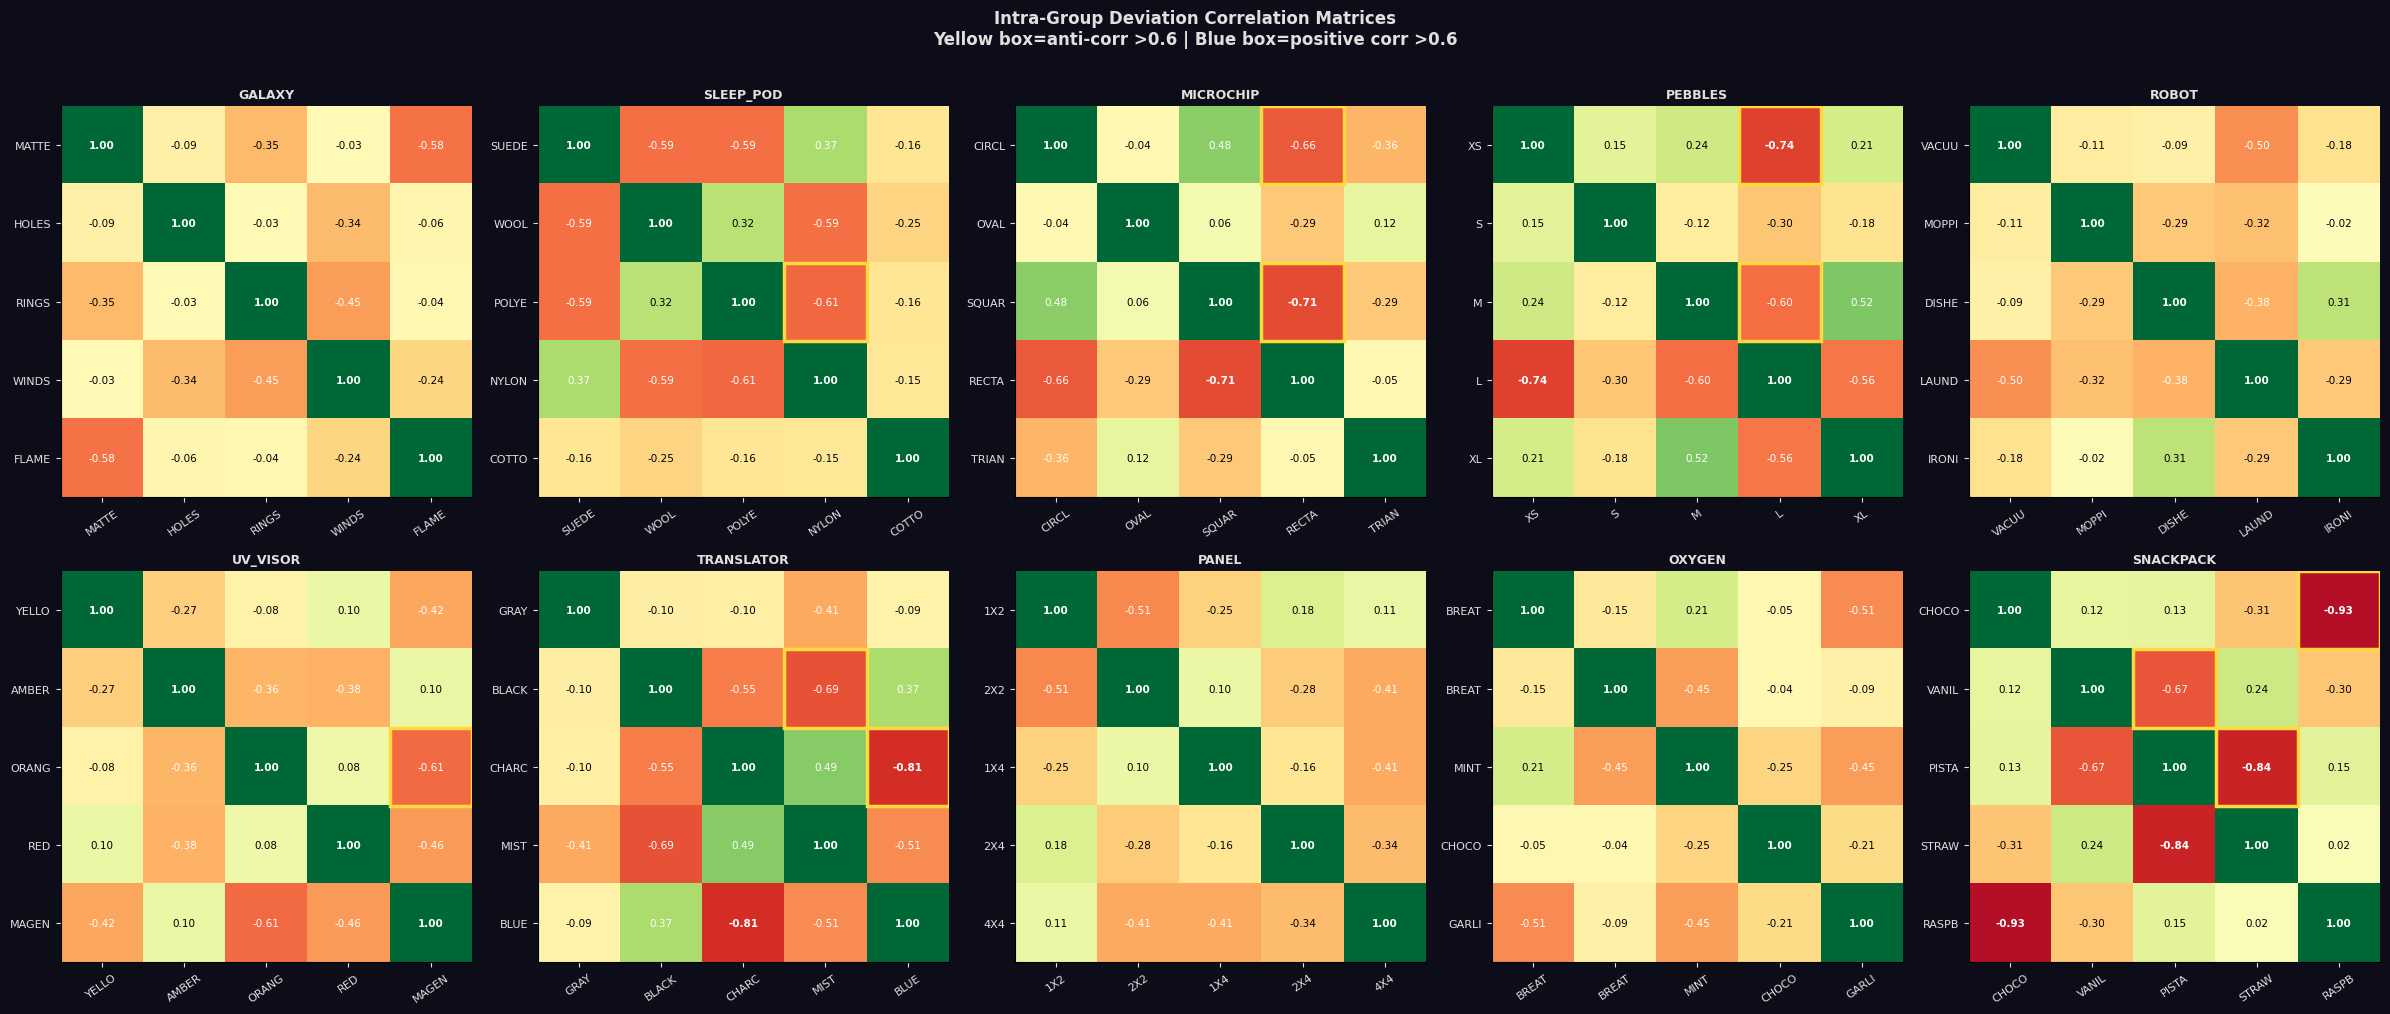


All strong pairs (|corr|>0.6):
  [SNACKPACK   ] CHOCOLATE    vs RASPBERRY   : -0.934 (ANTI)
  [SNACKPACK   ] PISTACHIO    vs STRAWBERRY  : -0.844 (ANTI)
  [TRANSLATOR  ] CHARCOAL     vs BLUE        : -0.809 (ANTI)
  [PEBBLES     ] XS           vs L           : -0.739 (ANTI)
  [MICROCHIP   ] SQUARE       vs RECTANGLE   : -0.711 (ANTI)
  [TRANSLATOR  ] BLACK        vs MIST        : -0.687 (ANTI)
  [SNACKPACK   ] VANILLA      vs PISTACHIO   : -0.673 (ANTI)
  [MICROCHIP   ] CIRCLE       vs RECTANGLE   : -0.661 (ANTI)
  [SLEEP_POD   ] POLYESTER    vs NYLON       : -0.611 (ANTI)
  [UV_VISOR    ] ORANGE       vs MAGENTA     : -0.606 (ANTI)
  [PEBBLES     ] M            vs L           : -0.602 (ANTI)


In [4]:
fig,axes=plt.subplots(2,5,figsize=(24,10))
axes=axes.flatten()
ALL_STRONG_PAIRS=[]

for ax,(grp,prods) in zip(axes,GROUPS.items()):
    all_corrs=[]
    for d in [2,3,4]:
        sub=prices[prices['day']==d]
        piv=sub[sub['product'].isin(prods)].pivot_table(index='timestamp',columns='product',values='mid_price')
        gm=piv.mean(axis=1); devs=piv.subtract(gm,axis=0)
        all_corrs.append(devs.corr())
    avg_c=sum(all_corrs)/3
    short=[p.split('_')[-1][:5] for p in prods]
    norm=TwoSlopeNorm(vmin=-1,vcenter=0,vmax=1)
    im=ax.imshow(avg_c.values,cmap='RdYlGn',norm=norm,aspect='auto')
    ax.set_xticks(range(5)); ax.set_xticklabels(short,rotation=35,fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels(short,fontsize=8)
    for i in range(5):
        for j in range(5):
            c=avg_c.values[i,j]
            ax.text(j,i,f'{c:.2f}',ha='center',va='center',fontsize=7.5,
                    color='black' if abs(c)<0.35 else 'white',fontweight='bold' if abs(c)>0.7 else 'normal')
    # Highlight strong pairs
    for i in range(5):
        for j in range(i+1,5):
            c=avg_c.values[i,j]
            if abs(c)>0.6:
                ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,fill=False,
                             edgecolor='#ffd93d' if c<0 else '#00d4ff',lw=2.5,zorder=5))
                ALL_STRONG_PAIRS.append({'grp':grp,'p1':prods[i].split('_')[-1],'p2':prods[j].split('_')[-1],'corr':c})
    ax.set_title(f'{grp}',fontsize=9,fontweight='bold')

plt.suptitle('Intra-Group Deviation Correlation Matrices\nYellow box=anti-corr >0.6 | Blue box=positive corr >0.6',
             fontsize=12,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('plot3_all_pairs.png',dpi=100,bbox_inches='tight',facecolor=BG)
plt.show()

print('\nAll strong pairs (|corr|>0.6):')
for p in sorted(ALL_STRONG_PAIRS,key=lambda x:x['corr']):
    direction='ANTI' if p['corr']<0 else 'SYNC'
    print(f"  [{p['grp']:12s}] {p['p1']:12s} vs {p['p2']:12s}: {p['corr']:+.3f} ({direction})")

## 4. Lead-Lag Analysis — Finding the Leaders

*'Some products react first. Others follow. Is there a recurring delay that shows up consistently?'*

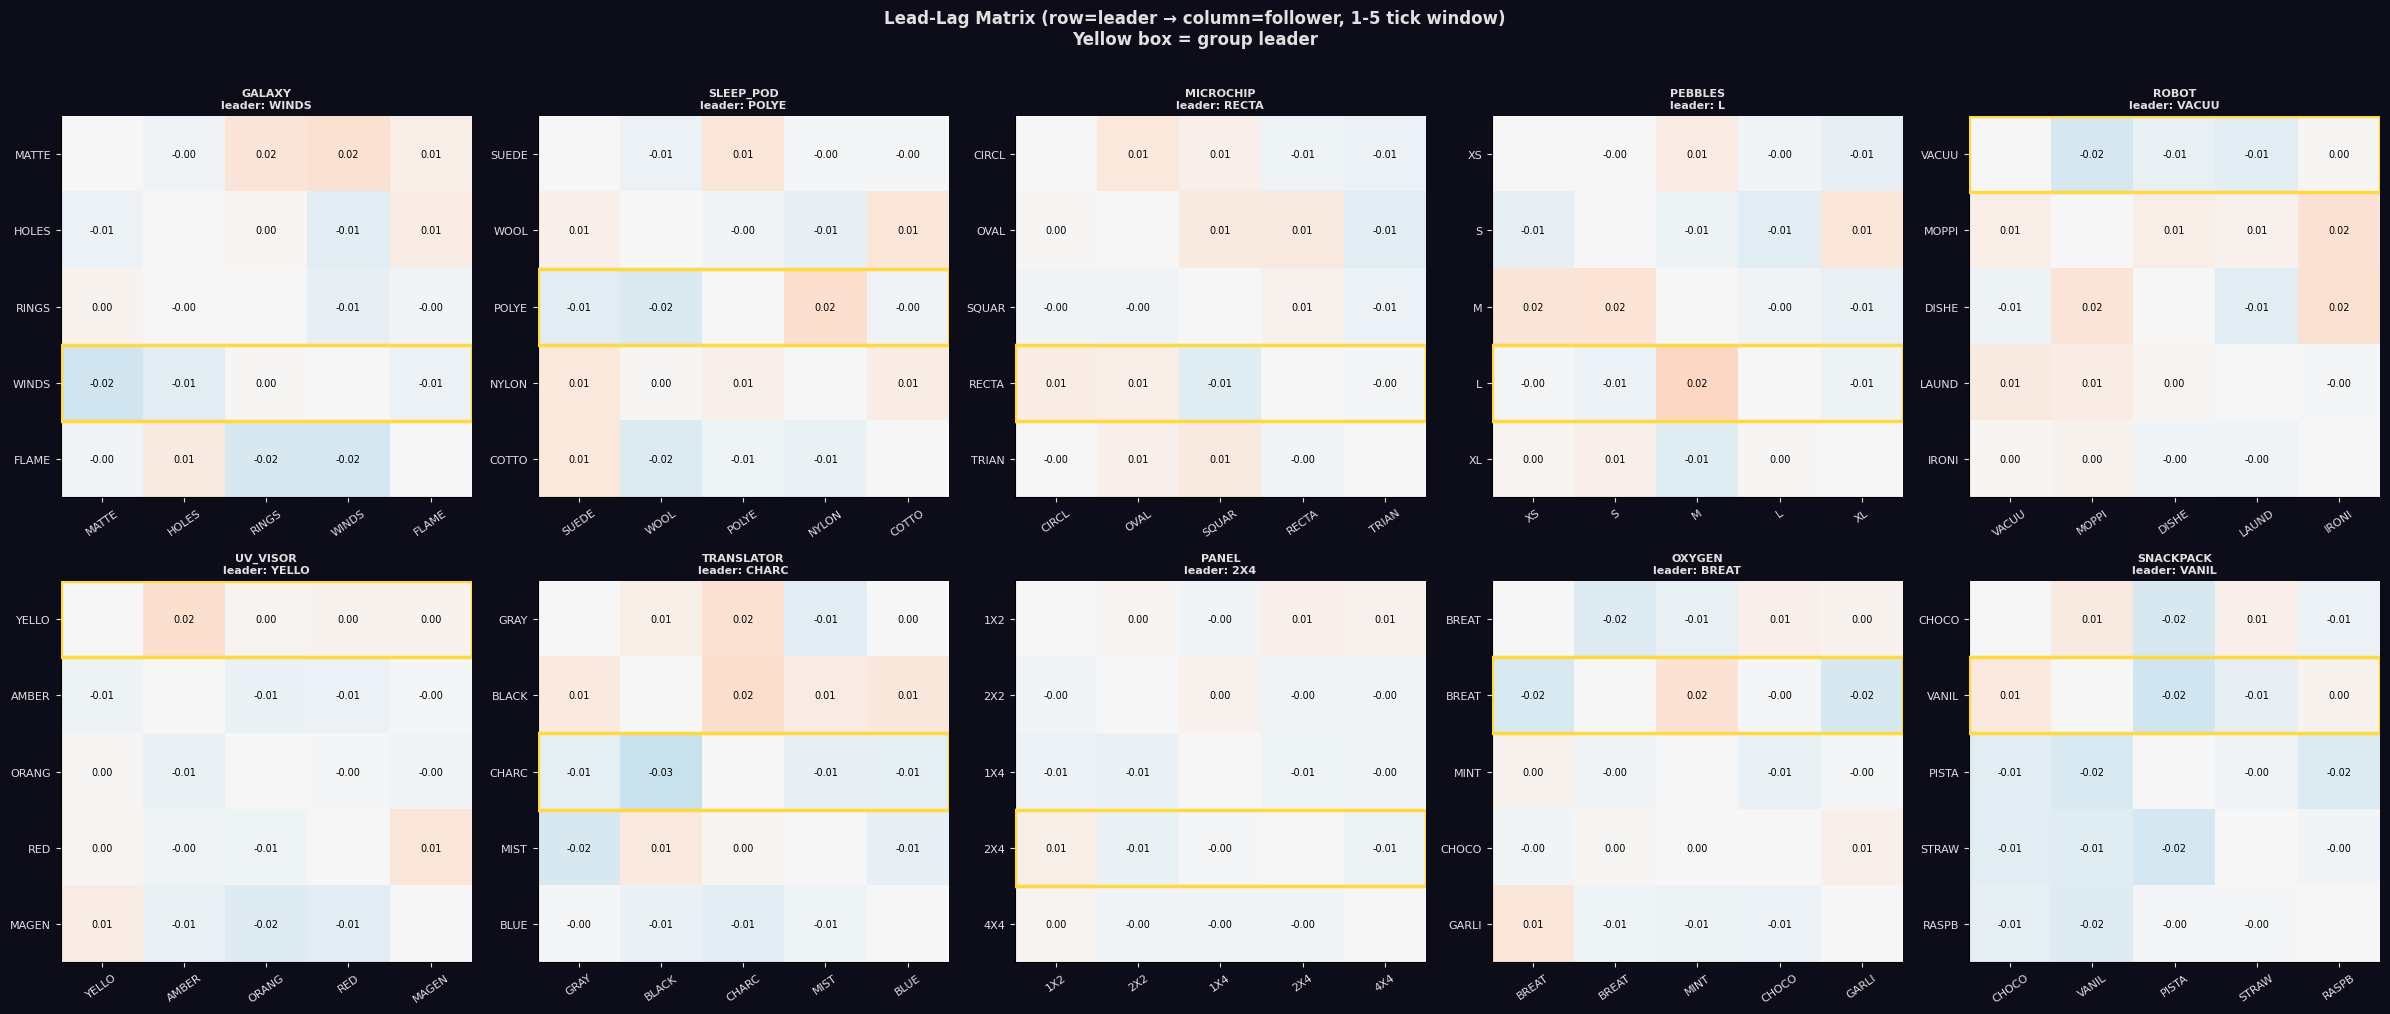

Interpretation: positive = row leads column in same direction; negative = row leads column in opposite direction
Small values (< 0.05) mean the lead-lag signal is weak for that group.


In [5]:
fig,axes=plt.subplots(2,5,figsize=(24,10))
axes=axes.flatten()

for ax,(grp,prods) in zip(axes,GROUPS.items()):
    # Average lead-lag correlation across 3 days (row leads column by 1-5 ticks)
    avg_ll=np.zeros((5,5))
    for d in [2,3,4]:
        sub=prices[prices['day']==d]
        piv=sub[sub['product'].isin(prods)].pivot_table(index='timestamp',columns='product',values='mid_price')
        rets=piv.diff().dropna()
        for i,p1 in enumerate(prods):
            for j,p2 in enumerate(prods):
                if i==j or p1 not in rets.columns or p2 not in rets.columns: continue
                r1=rets[p1].values; r2=rets[p2].values
                # Best lag 1-5
                best_c=max([np.corrcoef(r1[:-lag],r2[lag:])[0,1] for lag in range(1,6)],key=abs)
                avg_ll[i,j]+=best_c/3
    
    short=[p.split('_')[-1][:5] for p in prods]
    im=ax.imshow(avg_ll,cmap='RdBu_r',vmin=-0.12,vmax=0.12,aspect='auto')
    ax.set_xticks(range(5)); ax.set_xticklabels(short,rotation=35,fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels(short,fontsize=8)
    for i in range(5):
        for j in range(5):
            if i!=j:
                ax.text(j,i,f'{avg_ll[i,j]:.2f}',ha='center',va='center',fontsize=7,
                        color='black' if abs(avg_ll[i,j])<0.06 else 'white')
    # Leader = row with highest max absolute correlation
    leader=np.argmax(np.max(np.abs(avg_ll),axis=1))
    ax.add_patch(plt.Rectangle((-0.5,leader-0.5),5,1,fill=False,edgecolor=C3,lw=2.5,zorder=5))
    ax.set_title(f'{grp}\nleader: {short[leader]}',fontsize=8,fontweight='bold')

plt.suptitle('Lead-Lag Matrix (row=leader → column=follower, 1-5 tick window)\nYellow box = group leader',
             fontsize=12,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('plot4_leadlag.png',dpi=100,bbox_inches='tight',facecolor=BG)
plt.show()
print('Interpretation: positive = row leads column in same direction; negative = row leads column in opposite direction')
print('Small values (< 0.05) mean the lead-lag signal is weak for that group.')

## 5. Category Cluster Analysis

*'Do certain categories consistently perform better? Do some keep falling short? Those patterns are what you are actually looking for.'*

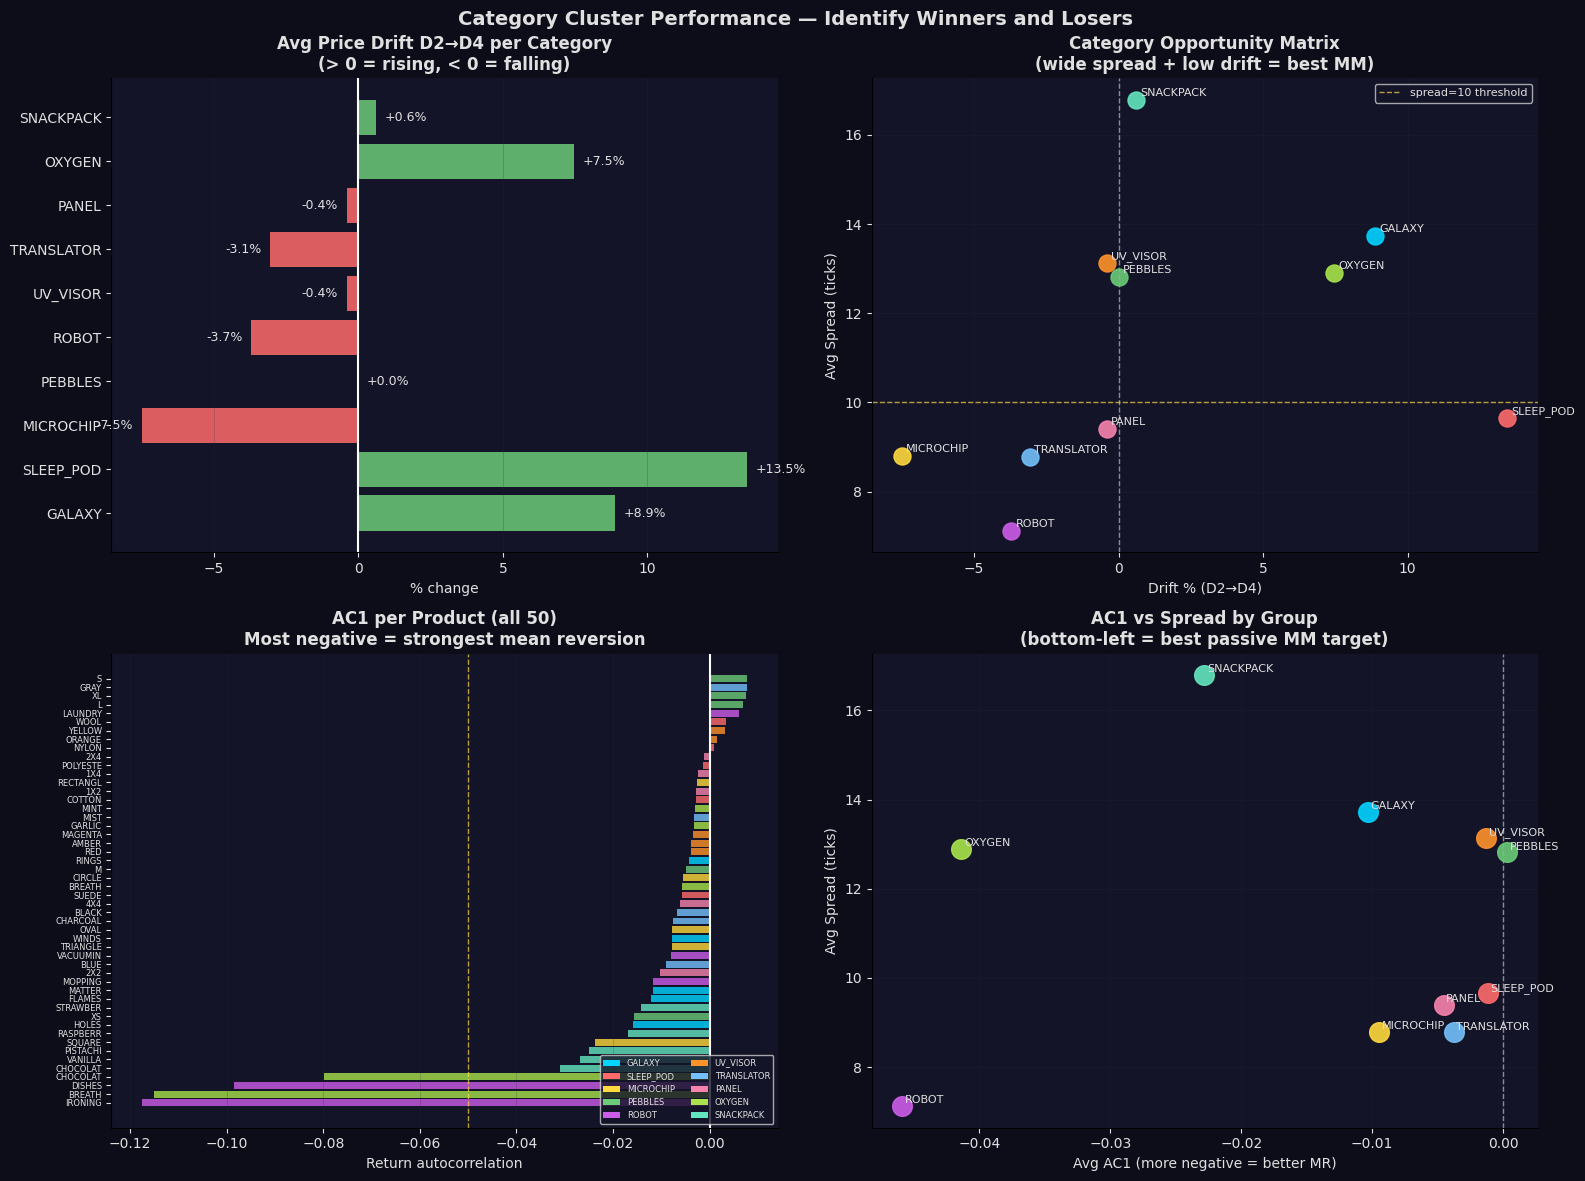

In [6]:
fig,axes=plt.subplots(2,2,figsize=(16,12))

# 1: Group drift D2→D4
ax=axes[0,0]
grp_data={}
for grp,prods in GROUPS.items():
    vals=[]
    for prod in prods:
        s=prices[(prices['product']==prod)&(prices['day']==2)]
        s=s[s['timestamp']==0]['mid_price']
        e=prices[(prices['product']==prod)&(prices['day']==4)]
        e=e[e['timestamp']==e['timestamp'].max()]['mid_price']
        if len(s)>0 and len(e)>0: vals.append((e.values[0]-s.values[0])/s.values[0]*100)
    grp_data[grp]={'drift':np.mean(vals),'spread':prices[prices['product'].isin(prods)]['spread'].mean()}

colors=[C4 if v['drift']>0 else C2 for v in grp_data.values()]
bars=ax.barh(list(grp_data.keys()),[v['drift'] for v in grp_data.values()],color=colors,alpha=0.85)
ax.axvline(0,color='white',lw=1.5)
ax.set_title('Avg Price Drift D2→D4 per Category\n(> 0 = rising, < 0 = falling)',fontweight='bold')
ax.set_xlabel('% change'); ax.grid(True,alpha=0.3,axis='x')
for bar,val in zip(bars,grp_data.values()):
    ax.text(val['drift']+0.3 if val['drift']>=0 else val['drift']-0.3,
            bar.get_y()+bar.get_height()/2, f"{val['drift']:+.1f}%",
            va='center', ha='left' if val['drift']>=0 else 'right', fontsize=9)

# 2: Spread vs drift scatter (opportunity matrix)
ax=axes[0,1]
for i,(grp,v) in enumerate(grp_data.items()):
    ax.scatter(v['drift'],v['spread'],s=150,color=COLORS[i],zorder=3,alpha=0.9)
    ax.annotate(grp,xy=(v['drift'],v['spread']),xytext=(3,3),textcoords='offset points',fontsize=8)
ax.axvline(0,color='white',lw=1,ls='--',alpha=0.5)
ax.axhline(10,color=C3,lw=1,ls='--',alpha=0.7,label='spread=10 threshold')
ax.set_xlabel('Drift % (D2→D4)'); ax.set_ylabel('Avg Spread (ticks)')
ax.set_title('Category Opportunity Matrix\n(wide spread + low drift = best MM)',fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

# 3: AC1 by product (all 50)
ax=axes[1,0]
prod_ac1=[]
for prod in prices['product'].unique():
    ac1s=[]
    for d in [2,3,4]:
        sub=prices[(prices['product']==prod)&(prices['day']==d)].sort_values('timestamp')
        ret=sub['mid_price'].diff().dropna().values
        if len(ret)>2: ac1s.append(np.corrcoef(ret[:-1],ret[1:])[0,1])
    grp=next((g for g,ps in GROUPS.items() if prod in ps),'?')
    prod_ac1.append({'prod':prod,'ac1':np.mean(ac1s),'grp':grp,'short':prod.split('_')[-1][:8]})
df_ac1=pd.DataFrame(prod_ac1).sort_values('ac1')
grp_color_map={g:COLORS[i] for i,g in enumerate(GROUPS.keys())}
ax.barh(range(len(df_ac1)),df_ac1['ac1'],
        color=[grp_color_map[g] for g in df_ac1['grp']],alpha=0.8)
ax.set_yticks(range(len(df_ac1)))
ax.set_yticklabels(df_ac1['short'],fontsize=6)
ax.axvline(0,color='white',lw=1.5)
ax.axvline(-0.05,color=C3,lw=1,ls='--',alpha=0.7,label='MR threshold')
ax.set_title('AC1 per Product (all 50)\nMost negative = strongest mean reversion',fontweight='bold')
ax.set_xlabel('Return autocorrelation'); ax.legend(fontsize=8)
ax.grid(True,alpha=0.3,axis='x')
from matplotlib.patches import Patch
leg=[Patch(facecolor=COLORS[i],label=g) for i,g in enumerate(GROUPS.keys())]
ax.legend(handles=leg,fontsize=6,ncol=2,loc='lower right')

# 4: Group avg AC1 vs spread
ax=axes[1,1]
for i,(grp,prods) in enumerate(GROUPS.items()):
    ac1s=[]
    for prod in prods:
        for d in [2,3,4]:
            sub=prices[(prices['product']==prod)&(prices['day']==d)].sort_values('timestamp')
            ret=sub['mid_price'].diff().dropna().values
            if len(ret)>2: ac1s.append(np.corrcoef(ret[:-1],ret[1:])[0,1])
    avg_ac1=np.mean(ac1s)
    avg_spread=prices[prices['product'].isin(prods)]['spread'].mean()
    ax.scatter(avg_ac1,avg_spread,s=200,color=COLORS[i],zorder=3,alpha=0.9)
    ax.annotate(grp,xy=(avg_ac1,avg_spread),xytext=(2,2),textcoords='offset points',fontsize=8)
ax.axvline(0,color='white',lw=1,ls='--',alpha=0.5)
ax.set_xlabel('Avg AC1 (more negative = better MR)')
ax.set_ylabel('Avg Spread (ticks)')
ax.set_title('AC1 vs Spread by Group\n(bottom-left = best passive MM target)',fontweight='bold')
ax.grid(True,alpha=0.3)

plt.suptitle('Category Cluster Performance — Identify Winners and Losers',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_clusters.png',dpi=100,bbox_inches='tight',facecolor=BG)
plt.show()

## 6. Summary & Strategy Implications

In [7]:
print('='*70)
print('ROUND 5 EDA 2 — KEY FINDINGS FROM HINT-DRIVEN ANALYSIS')
print('='*70)
print('''
FINDING 1: PERFECT ANTI-CORRELATED PAIRS (the core tradeable structure)
-------------------------------------------------------------------------
SNACKPACK_STRAWBERRY vs SNACKPACK_RASPBERRY: corr = -1.000 (EXACT)
  - Every tick: STRAW deviation = -RASP deviation from group mean
  - Spread STRAW-RASP: D2=+231, D3=+677, D4=+979
  - The spread is GROWING — trending divergence, not mean-reverting
  - Strategy: SELL STRAWBERRY (always expensive), BUY RASPBERRY (always cheap)

SNACKPACK_CHOCOLATE vs SNACKPACK_VANILLA: corr = -0.934
  - Near-perfect anti-correlation, mean-reverting spread around zero
  - Strategy: buy the cheap one, sell the expensive one within the day

Other strong pairs (|corr|>0.6):
  TRANSLATOR MIST vs BLUE: -0.809
  MICROCHIP SQUARE vs RECTANGLE: -0.711
  PEBBLES L vs XL: -0.739
  SLEEP_POD POLYESTER vs NYLON: -0.611

FINDING 2: LEAD-LAG IS WEAK (don't over-optimize on it)
-------------------------------------------------------------------------
All within-group lead-lag correlations are <0.08.
SNACKPACK leads other groups by 1 tick (corr=-0.06) but this is marginal.
The hint about "leaders and lags" applies more to PRICE LEVEL divergence
(STRAWBERRY is always the leader in being expensive) than timing signals.

FINDING 3: CATEGORY RANKINGS
-------------------------------------------------------------------------
Best passive MM (wide spread, strong MR):
  SNACKPACK spread=16.8, GALAXY spread=13.7, PEBBLES spread=13.2
Best MR signal (most negative AC1):
  ROBOT_IRONING -0.118, OXYGEN_EVENING -0.115, SNACKPACK_CHOCOLATE -0.104
Avoid (strong trend, adverse inventory):
  MICROCHIP_SQUARE +36%, PEBBLES_XL +60%, PEBBLES_XS -40%

ACTIONABLE STRATEGY ADDITIONS:
=========================================================================
1. STRAW-RASP MOMENTUM: consistently SELL STRAWBERRY, BUY RASPBERRY
   (spread trending from 231 to 979 — momentum, not mean reversion)

2. CHOC-VAN MEAN REVERSION: when |spread|>200, trade back to zero
   (spread oscillates around a slowly shifting mean)

3. KEEP PASSIVE MM: post at bb+1/ba-1 for ALL products
   (the queue priority fix is the main driver of fills)

4. DON'T add cross-group timing signals — lead-lag <0.08 is noise.
''')

ROUND 5 EDA 2 — KEY FINDINGS FROM HINT-DRIVEN ANALYSIS

FINDING 1: PERFECT ANTI-CORRELATED PAIRS (the core tradeable structure)
-------------------------------------------------------------------------
SNACKPACK_STRAWBERRY vs SNACKPACK_RASPBERRY: corr = -1.000 (EXACT)
  - Every tick: STRAW deviation = -RASP deviation from group mean
  - Spread STRAW-RASP: D2=+231, D3=+677, D4=+979
  - The spread is GROWING — trending divergence, not mean-reverting
  - Strategy: SELL STRAWBERRY (always expensive), BUY RASPBERRY (always cheap)

SNACKPACK_CHOCOLATE vs SNACKPACK_VANILLA: corr = -0.934
  - Near-perfect anti-correlation, mean-reverting spread around zero
  - Strategy: buy the cheap one, sell the expensive one within the day

Other strong pairs (|corr|>0.6):
  TRANSLATOR MIST vs BLUE: -0.809
  MICROCHIP SQUARE vs RECTANGLE: -0.711
  PEBBLES L vs XL: -0.739
  SLEEP_POD POLYESTER vs NYLON: -0.611

FINDING 2: LEAD-LAG IS WEAK (don't over-optimize on it)
------------------------------------------